# sci-CAR Analysis

In [22]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.preprocessing import normalize


In [23]:
cell_embeddings = (pd.read_csv('../embeddings/scoit/sci_CAR/cell_embeddings.csv', header=None))
labels = np.loadtxt("../data/sci_CAR/label.txt").astype(int)


In [24]:
np.max(labels), np.min(labels)

(13, 0)

## Cell Embeddings

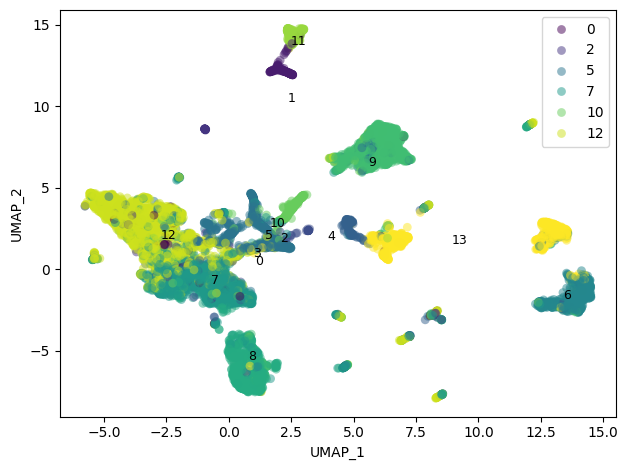

In [27]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

# plt.figure(figsize=(6,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=labels,
                hue_order=sorted(set(labels)), palette="viridis",
                s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")

# ---- 计算每个类的中心并标注 ----
df = pd.DataFrame({'UMAP_1': vec[:, 0], 'UMAP_2': vec[:, 1], 'label': labels})
centroids = df.groupby('label')[['UMAP_1', 'UMAP_2']].mean()

for label, row in centroids.iterrows():
    plt.text(row['UMAP_1'], row['UMAP_2'], str(label),
             fontsize=9, ha='center', va='center',)
plt.tight_layout()

## Cell Clustering

In [26]:
from scoit.cell_analysis import cluster_evaluate

cluster_evaluate(cell_embeddings, labels)

{'NMI': 0.5186459425808578,
 'ARI': 0.3938036163394032,
 'FMI': 0.4727095904604616}